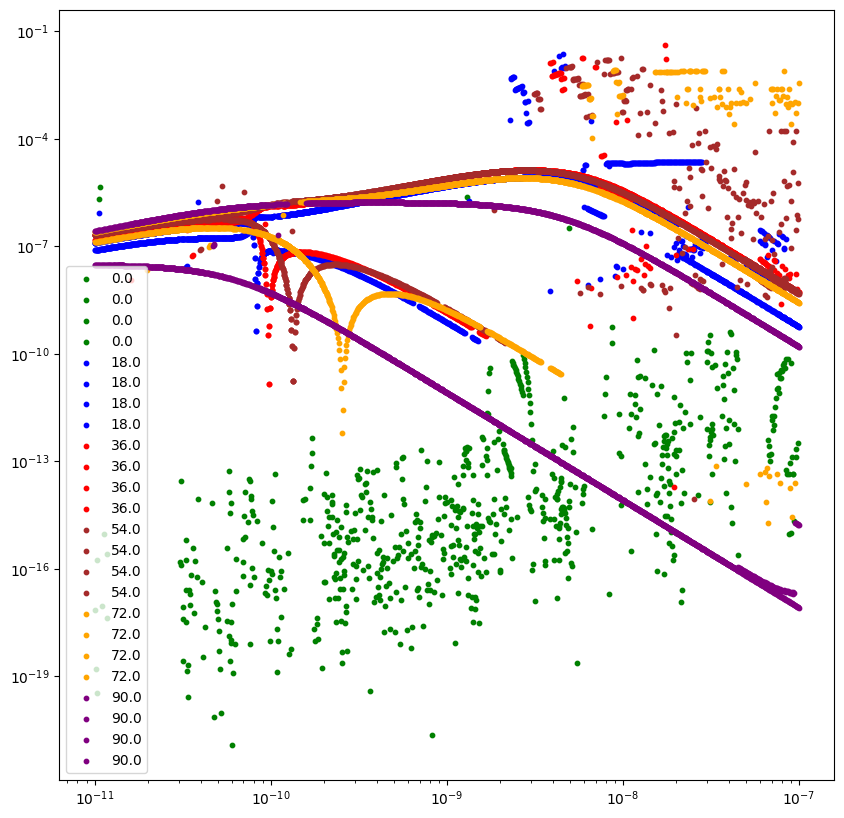

In [7]:
import numpy as np
import matplotlib.pyplot as plt
# 並列化用ライブラリ、引数操作用ライブラリをインポート
import multiprocessing
from functools import partial
from scipy.optimize import fsolve


#質量
#プラズマ周波数(電子のサイクロトロン周波数で規格化)
#サイクロトロン周波数(電子のサイクロトロン周波数で規格化)
# Constants
c = 3e8
me = 9.1093837015e-31
mh = 1.67262192e-27
a = 0.6 # proton and oxygen ratio
electron_cycltrons_seconds = 1

# Initialize plasma parameters
def init_plasma_params():
    oe, pe = 1.0*electron_cycltrons_seconds , 1.6*electron_cycltrons_seconds
    protons = {
        "mass": mh,
        "charge_sign": 1.0,
        "Cyclotron_freq": oe * me / mh,
        "Plasma_freq": pe * np.sqrt(a * me / mh),
        "name":"proton"
    }

    electrons = {
        "mass": me,
        "charge_sign": -1.0,
        "Cyclotron_freq": oe,
        "Plasma_freq": pe,
        "name": "electron"
    }
    return {"electron": electrons,"proton": protons}

elements = init_plasma_params()

if("electron" in elements):
  electron_plasma_freq = elements["electron"]["Plasma_freq"]
  electron_plasma_cycltrons = elements["electron"]["Cyclotron_freq"]
if("proton" in elements):
  proton_plasma_freq = elements["proton"]["Plasma_freq"]
  proton_plasma_cycltrons = elements["proton"]["Cyclotron_freq"]

# 分散関係の計算を関数化
def calc_disp(w,wave_num_tensor):
  K_perp = 1.0+0.0j
  K_x = 0.0j
  K_para = 1.0+0.0j
  w_rc = w[0] + w[1]*1.0j

  for element in elements.values():
    plasma_frequencies = element["Plasma_freq"]
    plasma_cycltrons = element["Cyclotron_freq"]
    charge_sign = element["charge_sign"]
    K_perp -= plasma_frequencies**2.0/(w_rc**2.0-plasma_cycltrons**2.0)
    K_x += plasma_frequencies**2.0/(w_rc**2.0-plasma_cycltrons**2.0)*plasma_cycltrons*charge_sign/w_rc
    K_para -= plasma_frequencies**2.0/w_rc**2.0


  K_tensor = -np.array([[K_para,0.0j,0.0j],[0.0j,K_perp,-1.0j*K_x],[0.0j,1.0j*K_x,K_perp]])


  matrix = w_rc**2.0/c**2.0*K_tensor + wave_num_tensor

  det = np.linalg.det(matrix)

  return np.array([det.real,det.imag])

fig, (ax1) = plt.subplots(1, 1, figsize=(10, 10))
#ax1.set_ylim(1e-6,10)

ax1.set_xscale('log')
ax1.set_yscale('log')


array_num = 1000
k_array_for_index = np.logspace(-11.0,-7.0,array_num)
w_res = np.zeros(array_num)
w_res2 = np.zeros(array_num)
w_res3 = np.zeros(array_num)
w_res4 = np.zeros(array_num)

theta_list = np.arange(0.*np.pi,0.51*np.pi,0.1*np.pi)


Gamma_val = (1.0/6e6) * np.array([[[-5.49523162e-09, 1.80752322e+00, 3.24065137e-34],
  [-1.80752322e+00,-1.37680623e-09,-7.74106543e-18],
  [-5.71043054e-25, 7.74106540e-18,-2.71720999e-35]],

 [[ 1.53160839e-10, 6.86125784e-01,-6.42164218e-18],
  [-6.86125790e-01, 1.71861620e-09,-4.75464892e-18],
  [ 6.42164206e-18, 4.75464890e-18,-6.16459489e-35]],

 [[ 2.25870672e-13,-1.10172075e-11, 5.91165011e-02],
  [ 1.77738184e-08, 8.51707317e-14,-1.48056124e-01],
  [-5.91165011e-02, 1.48056124e-01,-1.05833491e-19]]])

Gamma_val = np.array([[[0, 1e-12, 0],
  [0,0,0],
  [0,0,0]],
  [[0,0,0],
   [0,0,0],
  [0,0,0]],
 [[0,0,0],
   [0,0,0],
  [0,0,0]]])

#Gamma_val = np.zeros((3,3,3))

colors_index = ['green', 'blue', 'red', 'brown', 'orange', 'purple', 'black', 'yellow']

def upsilon(a,b,c):
  return Gamma_val[a][b][c] - Gamma_val[a][c][b]

for init in range(1):
  theta_count = -1
  for theta_index, theta in np.ndenumerate(theta_list):
    theta_count += 1
    for k_index, k in np.ndenumerate(k_array_for_index):
        karray = np.array([k*np.cos(theta),k*np.sin(theta),0])

        wave_num_tensor = np.full((3, 3), 0.0+0.0j)
        for kappa in range(3):
            for beta in range(3):
                wave_num_tensor[kappa][kappa] += karray[beta]**2.0
                for tau in range(3):
                    wave_num_tensor[kappa][kappa] += -1.0j*karray[beta]*upsilon(tau,beta,tau)

        for kappa in range(3):
            for neu in range(3):
                wave_num_tensor[kappa][neu] += -karray[kappa]*karray[neu]
                for tau in range(3):
                    wave_num_tensor[kappa][neu] += +1.0j*karray[kappa]*upsilon(tau,neu,tau)
                for beta in range(3):
                    wave_num_tensor[kappa][neu] +=1.0j*karray[beta]*(upsilon(beta,kappa,neu)+upsilon(neu,beta,kappa)) 
                    for tau in range(3):
                        wave_num_tensor[kappa][neu] += upsilon(beta,kappa,neu)*upsilon(tau,beta,tau)+0.5*upsilon(tau,beta,neu)*upsilon(tau,beta,kappa)    
                
        w_init = np.array([4e-4,0.0])
        #-1.0+init*0.2
        res = fsolve(calc_disp,w_init,args = wave_num_tensor,maxfev=10000)
        w_init[0] = 1e-1
        res2 = fsolve(calc_disp,w_init,args = wave_num_tensor,maxfev=10000)
        w_init[0] = 1e-2
        res3 = fsolve(calc_disp,w_init,args = wave_num_tensor,maxfev=10000)
        w_init[0] = 1e-5
        res4 = fsolve(calc_disp,w_init,args = wave_num_tensor,maxfev=10000)


        w_res[k_index] = res[1]
        w_res2[k_index] = res2[1]
        w_res3[k_index] = res3[1]
        w_res4[k_index] = res4[1]
    color= colors_index[theta_count]
    ax1.scatter(k_array_for_index,w_res,label = theta*180/np.pi, s= 10,c = color)
    ax1.scatter(k_array_for_index,w_res2,label = theta*180/np.pi, s= 10,c = color)
    ax1.scatter(k_array_for_index,w_res3,label = theta*180/np.pi, s= 10,c = color)
    ax1.scatter(k_array_for_index,w_res4,label = theta*180/np.pi, s= 10,c = color)
    if(init == 0):
        ax1.legend()
 
